In [1]:
from prophet import Prophet
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric, plot_yearly

import pandas as pd
import numpy as np
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 

from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler, StandardScaler



/home/henrique/miniconda3/envs/tf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Lendo os dados
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"

df = pd.concat([df, df])

In [3]:
new_index = pd.date_range(start=df.index.min(), periods=len(df), freq="MS")

df.index = new_index

In [4]:
values = df[3003858507].values
values = values.reshape((len(values), 1))

scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(values)

df_normalized = scaler.transform(values)

df["Normalized"] = df_normalized

df

,3003858507,3001084033,3011373971,3001449459,3011504476,Normalized
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0,0.177295
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0,0.131941
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0,0.160253
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0,0.260583
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0,0.396921
...,...,...,...,...,...,...
2026-07-01,1216.0,7440.0,920.0,1000.0,2280.0,0.169049
2026-08-01,1335.0,7240.0,360.0,840.0,2000.0,0.201759
2026-09-01,1317.0,7960.0,680.0,880.0,2160.0,0.196811
2026-10-01,2367.0,5880.0,800.0,840.0,2120.0,0.485432


In [5]:
df.reset_index(inplace=True)
df = df.rename(columns={"index": "DS"})

df.columns = ["ds", "y1", "y2", "y3", "y4", "y5", "yN"]

df["y1"] = df["y1"].astype(int)
df["y2"] = df["y2"].astype(int)
df["y3"] = df["y3"].astype(int)
df["y4"] = df["y4"].astype(int)
df["y5"] = df["y5"].astype(int)
df["yN"] = df["yN"].astype(int)

df.columns = ["ds", "y1", "y2", "y3", "y4", "y5", "y"]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      90 non-null     datetime64[ns]
 1   y1      90 non-null     int64         
 2   y2      90 non-null     int64         
 3   y3      90 non-null     int64         
 4   y4      90 non-null     int64         
 5   y5      90 non-null     int64         
 6   y       90 non-null     int64         
dtypes: datetime64[ns](1), int64(6)
memory usage: 5.0 KB


In [6]:
train = df.iloc[:80]
test = df.iloc[79:]

m = Prophet(growth="flat", seasonality_mode="additive", yearly_seasonality=150)


m.fit(train)
future = m.make_future_dataframe(periods=12, freq="MS")
forecast = m.predict(future)

14:09:34 - cmdstanpy - INFO - Chain [1] start processing
14:09:36 - cmdstanpy - INFO - Chain [1] done processing


<AxesSubplot:xlabel='ds'>

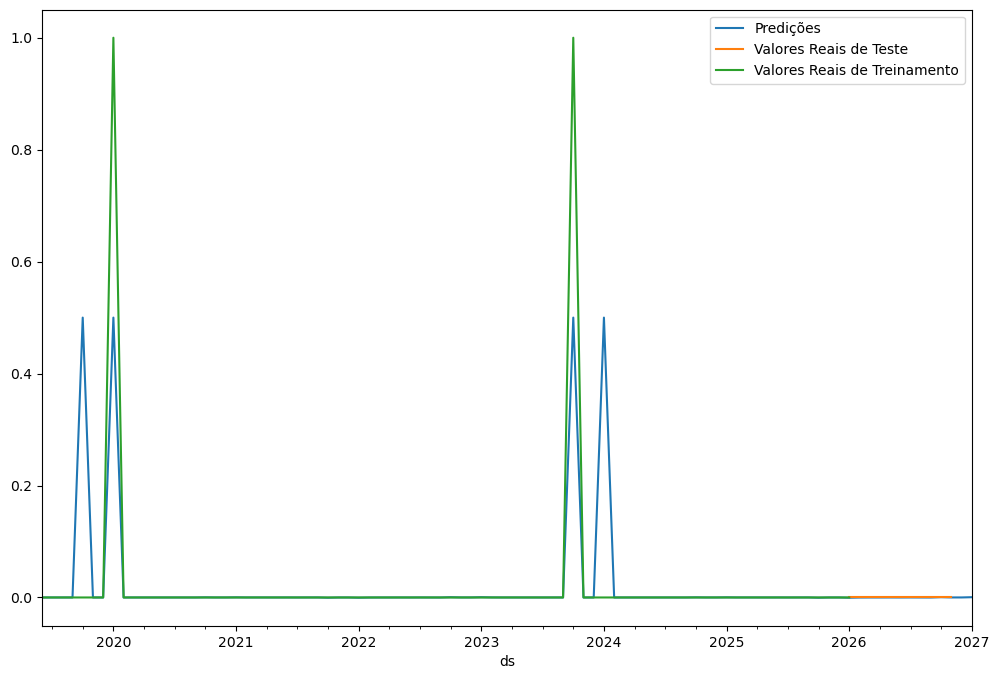

In [7]:
ax = forecast.plot(x="ds", y="yhat", label="Predições", legend=True, figsize=(12, 8))
test.plot(x="ds", y="y", label="Valores Reais de Teste", legend=True, ax=ax)
train.plot(x="ds", y="y", label="Valores Reais de Treinamento", legend=True, ax=ax)

In [8]:
df_cv = cross_validation(m, initial="36 days", period="36 days", horizon="12 days")

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  8%|▊         | 3/39 [00:00<00:01, 20.42it/s]14:09:37 - cmdstanpy - INFO - Chain [1] start processing
14:09:48 - cmdstanpy - INFO - Chain [1] done processing
14:09:48 - cmdstanpy - INFO - Chain [1] start processing
14:09:52 - cmdstanpy - INFO - Chain [1] done processing
14:09:52 - cmdstanpy - INFO - Chain [1] start processing
 15%|█▌        | 6/39 [00:32<03:30,  6.38s/it]14:10:09 - cmdstanpy - INFO - Chain [1] start processing
14:10:39 - cmdstanpy - INFO - Chain [1] done processing
 18%|█▊        | 7/39 [01:02<06:09, 11.56s/it]14:10:39 - cmdstanpy - INFO - Chain [1] start processing
14:11:46 - cmdstanpy - INFO - Chain [1] done processing
 21%|██        | 8/39 [02:09<12:49, 24.84s/it]14:11:47 - cmdstanpy - INFO - Chain [1] start processing
14:12:09 - cmdstanpy - INFO - Chain [1] done processing
 23%|██▎       | 9/39 [02:32<12:08, 24.28s/it]14:12:09 - cmdstanpy - INFO - Chain [1] star

KeyboardInterrupt: 

In [ ]:
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,12 days,9.796498e+08,31299.358009,18102.896412,10.06057,1.573751,1.131417,0.179487


In [ ]:
m = Prophet(growth='flat', seasonality_mode='additive',yearly_seasonality=150)

m.fit(df)

future = m.make_future_dataframe(periods=48,freq='MS')

forecast = m.predict(future)

forecast.head()

17:49:05 - cmdstanpy - INFO - Chain [1] start processing
17:49:06 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-06-01,77.28628,1100.330167,2082.591150,77.28628,77.28628,1542.469757,1542.469757,1542.469757,1542.469757,1542.469757,1542.469757,0.0,0.0,0.0,1619.756037
1,2019-07-01,77.28628,990.598470,1947.995140,77.28628,77.28628,1403.017858,1403.017858,1403.017858,1403.017858,1403.017858,1403.017858,0.0,0.0,0.0,1480.304138
2,2019-08-01,77.28628,1661.401150,2627.263345,77.28628,77.28628,2062.712181,2062.712181,2062.712181,2062.712181,2062.712181,2062.712181,0.0,0.0,0.0,2139.998461
3,2019-09-01,77.28628,1296.717590,2346.307658,77.28628,77.28628,1742.698751,1742.698751,1742.698751,1742.698751,1742.698751,1742.698751,0.0,0.0,0.0,1819.985031
4,2019-10-01,77.28628,1476.912339,2496.997462,77.28628,77.28628,1902.777291,1902.777291,1902.777291,1902.777291,1902.777291,1902.777291,0.0,0.0,0.0,1980.063571


<AxesSubplot:xlabel='ds'>

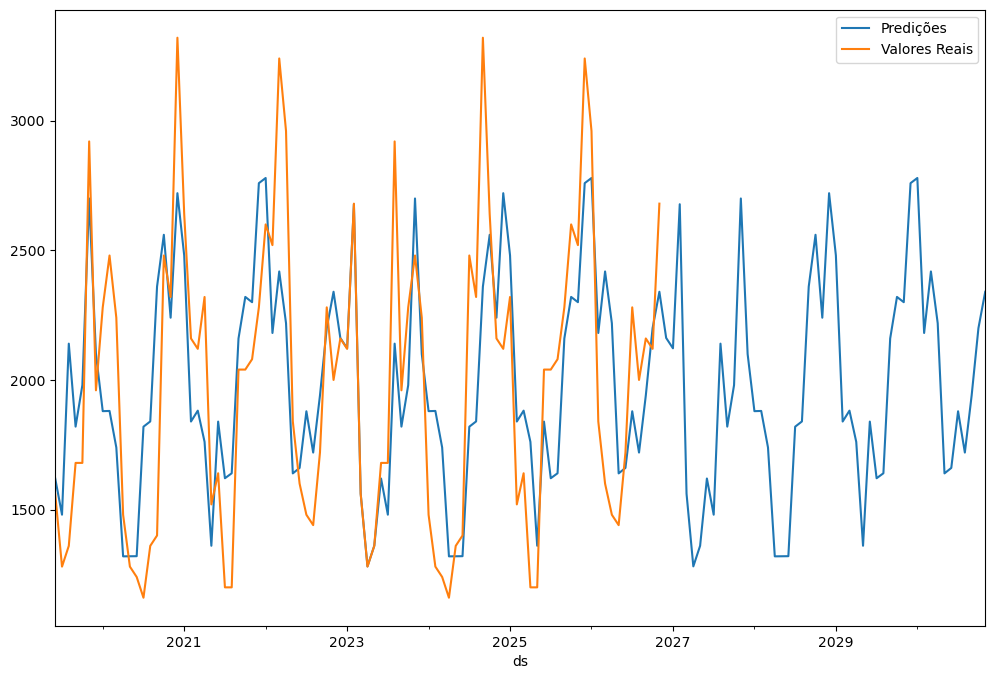

In [ ]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
df.plot(x='ds',y='y',label='Valores Reais',legend=True,ax=ax)